# Compare Model Outputs

Compares model outputs across runs using the composite objective score. Lower is better.

If `objective_score` is missing, the notebook falls back to time columns (`total_time` or `best_time`).

In [4]:
import csv
import itertools
from pathlib import Path
from scipy import stats

def _resolve_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return paths[0]

OUT = _resolve_existing([Path("outputs"), Path("../outputs")])

FILES = {
    "exact_mip":       OUT / "exact_mip_all_runs_summary.csv",
    "baseline_greedy": OUT / "baseline_greedy_all_runs_summary.csv",
    "baseline_beam":   OUT / "baseline_beam_all_runs_summary.csv",
    "baseline_random": OUT / "baseline_random_all_runs_summary.csv",
}

def _read_scores(path, candidates):
    if not path.exists():
        return {}
    with path.open("r", newline="") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        return {}
    field = next((c for c in candidates if c in rows[0]), None)
    if field is None:
        return {}
    out = {}
    for r in rows:
        run = r.get("run_name", "canonical")
        try:
            out[run] = float(r[field])
        except (TypeError, ValueError):
            continue
    return out

SCORE_FIELDS = ["objective_score", "total_time", "best_time"]

times = {model: _read_scores(FILES[model], SCORE_FIELDS) for model in FILES}

all_runs = sorted(set().union(*[set(v.keys()) for v in times.values()]))
if not all_runs:
    raise RuntimeError("No model summary files found in outputs/. Run model notebooks first.")

# ── Per-run comparison ────────────────────────────────────────────────────────
comparison_rows = []
wins = {k: 0 for k in times}
for run in all_runs:
    row = {"run_name": run}
    best_model, best_val = None, None
    for model in FILES:
        v = times[model].get(run)
        row[model] = "" if v is None else v
        if v is not None and (best_val is None or v < best_val):
            best_val, best_model = v, model
    row["best_model"] = best_model or ""
    row["best_objective_score"] = "" if best_val is None else best_val
    if best_model:
        wins[best_model] += 1
    comparison_rows.append(row)

comparison_path = OUT / "model_output_comparison.csv"
with comparison_path.open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["run_name"] + list(FILES.keys()) + ["best_model", "best_objective_score"])
    w.writeheader()
    w.writerows(comparison_rows)

# ── Summary (mean + wins) ─────────────────────────────────────────────────────
summary_rows = []
model_vals = {}
for model in FILES:
    vals = [times[model][r] for r in all_runs if r in times[model]]
    model_vals[model] = vals
    avg = sum(vals) / len(vals) if vals else ""
    summary_rows.append({
        "model": model,
        "n_runs": len(vals),
        "mean_objective_score": avg,
        "win_count": wins[model],
    })

summary_path = OUT / "model_output_comparison_summary.csv"
with summary_path.open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["model", "n_runs", "mean_objective_score", "win_count"])
    w.writeheader()
    w.writerows(summary_rows)

print("Mean objective score by model (lower is better):")
for r in sorted(summary_rows, key=lambda x: float("inf") if x["mean_objective_score"] == "" else x["mean_objective_score"]):
    print(f"  {r['model']:20s}  mean={r['mean_objective_score']:.4f}  wins={r['win_count']}/{r['n_runs']}")

# ── Pairwise statistical tests ────────────────────────────────────────────────
ALPHA = 0.05
models = list(FILES.keys())
stat_rows = []

print(f"\nPairwise statistical tests (α={ALPHA}, paired, lower score = better):")
print(f"{'Model A':20s}  {'Model B':20s}  {'A mean':>8}  {'B mean':>8}  {'t p-val':>8}  {'W p-val':>8}  Conclusion")
print("-" * 110)

for a, b in itertools.combinations(models, 2):
    common = [r for r in all_runs if r in times[a] and r in times[b]]
    if len(common) < 2:
        continue
    va = [times[a][r] for r in common]
    vb = [times[b][r] for r in common]

    t_stat, t_p = stats.ttest_rel(va, vb)
    w_stat, w_p = stats.wilcoxon(va, vb)

    mean_a = sum(va) / len(va)
    mean_b = sum(vb) / len(vb)

    sig = t_p < ALPHA or w_p < ALPHA
    if sig:
        winner = a if mean_a < mean_b else b
        conclusion = f"{winner} significantly better"
    else:
        conclusion = "no significant difference"

    print(f"{a:20s}  {b:20s}  {mean_a:8.4f}  {mean_b:8.4f}  {t_p:8.4f}  {w_p:8.4f}  {conclusion}")
    stat_rows.append({
        "model_a": a, "model_b": b,
        "n_common_runs": len(common),
        "mean_a": mean_a, "mean_b": mean_b,
        "paired_ttest_pval": t_p,
        "wilcoxon_pval": w_p,
        "significant": sig,
        "conclusion": conclusion,
    })

stat_path = OUT / "model_output_comparison_stats.csv"
if stat_rows:
    with stat_path.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(stat_rows[0].keys()))
        w.writeheader()
        w.writerows(stat_rows)
    print(f"\nWrote: {stat_path}")

print(f"Wrote: {comparison_path}")
print(f"Wrote: {summary_path}")


Mean objective score by model (lower is better):
  exact_mip             mean=229.0761  wins=50/50
  baseline_random       mean=231.6721  wins=0/50
  baseline_beam         mean=319.9973  wins=0/50
  baseline_greedy       mean=335.7304  wins=0/50

Pairwise statistical tests (α=0.05, paired, lower score = better):
Model A               Model B                 A mean    B mean   t p-val   W p-val  Conclusion
--------------------------------------------------------------------------------------------------------------
exact_mip             baseline_greedy       229.0761  335.7304    0.0000    0.0000  exact_mip significantly better
exact_mip             baseline_beam         229.0761  319.9973    0.0000    0.0000  exact_mip significantly better
exact_mip             baseline_random       229.0761  231.6721    0.0011    0.0002  exact_mip significantly better
baseline_greedy       baseline_beam         335.7304  319.9973    0.0000    0.0000  baseline_beam significantly better
baseline_greedy 

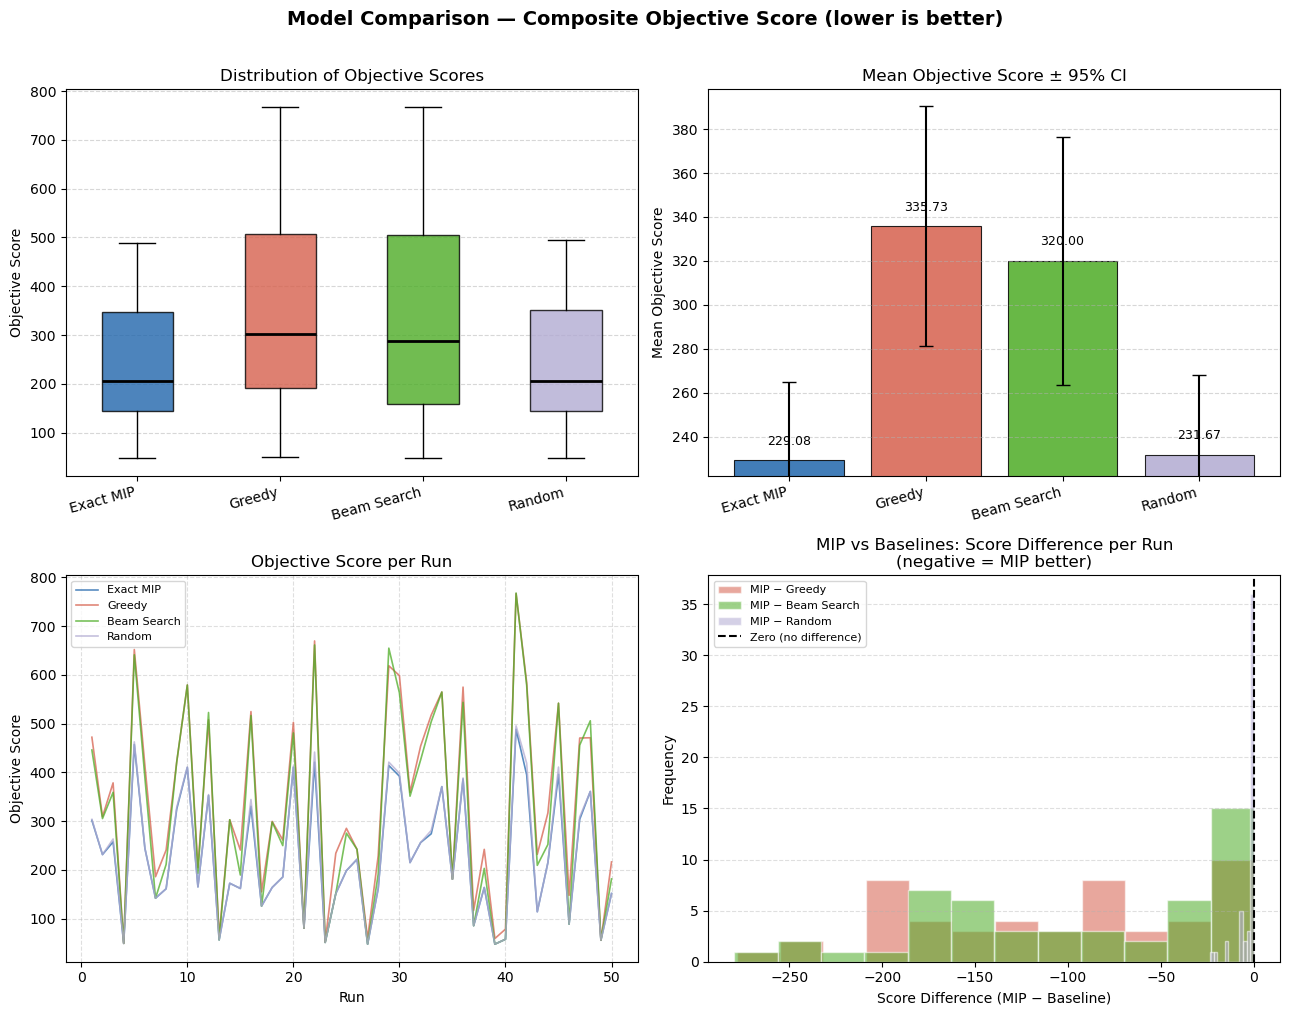

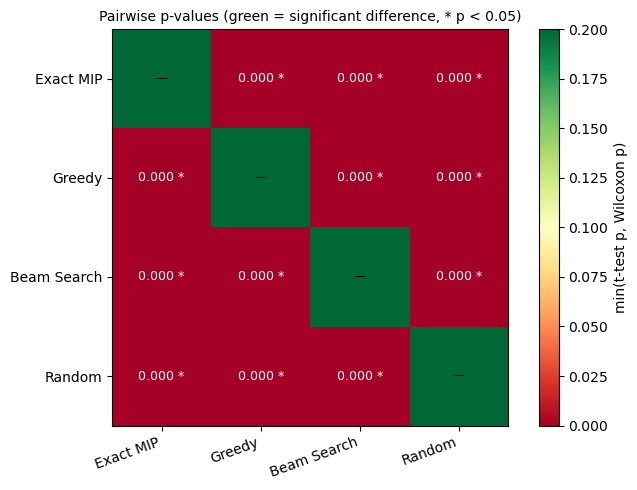

In [5]:
import matplotlib.pyplot as plt
import numpy as np

MODELS = ["exact_mip", "baseline_greedy", "baseline_beam", "baseline_random"]
LABELS = {"exact_mip": "Exact MIP", "baseline_greedy": "Greedy", "baseline_beam": "Beam Search", "baseline_random": "Random"}
COLORS = {"exact_mip": "#2166ac", "baseline_greedy": "#d6604d", "baseline_beam": "#4dac26", "baseline_random": "#b2abd2"}

common_runs = sorted(set.intersection(*[set(times[m].keys()) for m in MODELS if times[m]]))
scores = {m: [times[m][r] for r in common_runs] for m in MODELS}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Model Comparison — Composite Objective Score (lower is better)", fontsize=14, fontweight="bold", y=1.01)

# ── 1. Box plot ───────────────────────────────────────────────────────────────
ax = axes[0, 0]
data = [scores[m] for m in MODELS]
bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", linewidth=2), widths=0.5)
for patch, model in zip(bp["boxes"], MODELS):
    patch.set_facecolor(COLORS[model])
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(MODELS) + 1))
ax.set_xticklabels([LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Objective Score")
ax.set_title("Distribution of Objective Scores")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# ── 2. Mean ± 95% CI bar chart ────────────────────────────────────────────────
ax = axes[0, 1]
means = [np.mean(scores[m]) for m in MODELS]
n = len(common_runs)
sems = [np.std(scores[m], ddof=1) / np.sqrt(n) * 1.96 for m in MODELS]
x = np.arange(len(MODELS))
bars = ax.bar(x, means, yerr=sems, capsize=5, color=[COLORS[m] for m in MODELS], alpha=0.85, edgecolor="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Mean Objective Score")
ax.set_title("Mean Objective Score ± 95% CI")
ax.grid(axis="y", linestyle="--", alpha=0.5)
y_min = min(means) * 0.97
y_max = max(v + e for v, e in zip(means, sems)) * 1.02
ax.set_ylim(y_min, y_max)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(sems) * 0.1,
            f"{mean:.2f}", ha="center", va="bottom", fontsize=9)

# ── 3. Per-run scores line plot ───────────────────────────────────────────────
ax = axes[1, 0]
for model in MODELS:
    ax.plot(range(1, n + 1), scores[model], label=LABELS[model],
            color=COLORS[model], alpha=0.75, linewidth=1.2)
ax.set_xlabel("Run")
ax.set_ylabel("Objective Score")
ax.set_title("Objective Score per Run")
ax.legend(fontsize=8)
ax.grid(linestyle="--", alpha=0.4)

# ── 4. MIP vs baselines difference histograms ─────────────────────────────────
ax = axes[1, 1]
baselines = [m for m in MODELS if m != "exact_mip"]
for bl in baselines:
    diffs = [times["exact_mip"][r] - times[bl][r] for r in common_runs]
    ax.hist(diffs, bins=12, alpha=0.55, color=COLORS[bl], edgecolor="white", label=f"MIP − {LABELS[bl]}")
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="Zero (no difference)")
ax.set_xlabel("Score Difference (MIP − Baseline)")
ax.set_ylabel("Frequency")
ax.set_title("MIP vs Baselines: Score Difference per Run\n(negative = MIP better)")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ── 5. p-value heatmap ───────────────────────────────────────────────────────
if stat_rows:
    fig2, ax = plt.subplots(figsize=(7, 5))
    model_idx = {m: i for i, m in enumerate(MODELS)}
    pval_matrix = np.ones((len(MODELS), len(MODELS)))
    for row in stat_rows:
        i, j = model_idx[row["model_a"]], model_idx[row["model_b"]]
        p = min(row["paired_ttest_pval"], row["wilcoxon_pval"])
        pval_matrix[i, j] = p
        pval_matrix[j, i] = p

    im = ax.imshow(pval_matrix, cmap="RdYlGn", vmin=0, vmax=0.2)
    plt.colorbar(im, ax=ax, label="min(t-test p, Wilcoxon p)")
    ax.set_xticks(range(len(MODELS)))
    ax.set_yticks(range(len(MODELS)))
    ax.set_xticklabels([LABELS[m] for m in MODELS], rotation=20, ha="right")
    ax.set_yticklabels([LABELS[m] for m in MODELS])
    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            val = pval_matrix[i, j]
            txt = "—" if i == j else (f"{val:.3f}" + (" *" if val < 0.05 else ""))
            ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                    color="black" if val > 0.05 else "white")
    ax.set_title("Pairwise p-values (green = significant difference, * p < 0.05)", fontsize=10)
    plt.tight_layout()
    plt.show()
